In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [1]:
!pip install -q peft accelerate tensorboard

In [3]:
import os
import xml.etree.ElementTree as ET
import json
from PIL import Image
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import CLIPProcessor, CLIPModel
from peft import LoraConfig, get_peft_model
from tqdm import tqdm
import numpy as np
import matplotlib.pyplot as plt
import random

# 设置数据集路径（Kaggle挂载的数据集位置）
DATA_ROOT = "/kaggle/input/datasets/dongly/shipdataset/SeaShips(7000)"  # 注意检查这个路径是否正确，可能需要调整
print("数据集目录内容：", os.listdir(DATA_ROOT))

# 确认子文件夹存在
assert 'JPEGImages' in os.listdir(DATA_ROOT), "JPEGImages 文件夹不存在"
assert 'Annotations' in os.listdir(DATA_ROOT), "Annotations 文件夹不存在"
assert 'ImageSets' in os.listdir(DATA_ROOT), "ImageSets 文件夹不存在"

# 设置输出目录
OUTPUT_DIR = "./clip_ship_output"
os.makedirs(OUTPUT_DIR, exist_ok=True)

数据集目录内容： ['val.txt', 'test.txt', 'Annotations', '划分.py', 'ImageSets', 'train.txt', 'JPEGImages', '查看.py']


In [5]:
def parse_voc_annotation(xml_path):
    """解析单个XML文件，返回图片文件名和第一个物体的类别名"""
    tree = ET.parse(xml_path)
    root = tree.getroot()
    filename = root.find('filename').text
    obj = root.find('object')
    if obj is not None:
        class_name = obj.find('name').text
        return filename, class_name
    else:
        return filename, None

def collect_classes(annotations_dir):
    """遍历所有XML，收集所有类别名"""
    class_set = set()
    for xml_file in os.listdir(annotations_dir):
        if not xml_file.endswith('.xml'):
            continue
        xml_path = os.path.join(annotations_dir, xml_file)
        _, class_name = parse_voc_annotation(xml_path)
        if class_name:
            class_set.add(class_name)
    classes = sorted(list(class_set))
    return classes

def build_dataset(annotations_dir, images_dir, class_to_id, output_json, image_set_file=None):
    """根据ImageSets中的划分文件构建数据集JSON"""
    image_names = set()
    if image_set_file and os.path.exists(image_set_file):
        with open(image_set_file, 'r') as f:
            image_names = set(line.strip() for line in f)
    else:
        # 如果没有划分文件，则处理所有XML对应的图像
        for xml_file in os.listdir(annotations_dir):
            if xml_file.endswith('.xml'):
                image_names.add(xml_file.replace('.xml', ''))

    pairs = []
    for xml_file in tqdm(os.listdir(annotations_dir), desc="处理标注"):
        if not xml_file.endswith('.xml'):
            continue
        img_id = xml_file.replace('.xml', '')
        if img_id not in image_names:
            continue

        xml_path = os.path.join(annotations_dir, xml_file)
        filename, class_name = parse_voc_annotation(xml_path)
        if class_name is None:
            continue

        # 构建图像相对路径（相对于DATA_ROOT）
        image_rel_path = os.path.join(images_dir, filename)

        # 生成文本描述
        text = f"a photo of a {class_name} ship"

        pairs.append({
            "image_path": image_rel_path,
            "text": text,
            "class_id": class_to_id[class_name]
        })

    with open(output_json, 'w') as f:
        json.dump(pairs, f, indent=2)

    print(f"生成 {len(pairs)} 条数据到 {output_json}")
    return pairs

# 开始处理
annotations_dir = os.path.join(DATA_ROOT, 'Annotations')
images_dir = 'JPEGImages'  # 相对路径，后面会拼上DATA_ROOT
image_sets_dir = os.path.join(DATA_ROOT, 'ImageSets')

# 收集所有类别
classes = collect_classes(annotations_dir)
print("发现类别:", classes)
class_to_id = {name: i for i, name in enumerate(classes)}

# 保存类别映射
with open(os.path.join(OUTPUT_DIR, 'classes.json'), 'w') as f:
    json.dump(classes, f, indent=2)

# 处理训练集（如果有train.txt）
train_set_file = os.path.join(DATA_ROOT, 'train.txt')
if os.path.exists(train_set_file):
    train_pairs = build_dataset(
        annotations_dir=annotations_dir,
        images_dir=images_dir,
        class_to_id=class_to_id,
        output_json=os.path.join(OUTPUT_DIR, 'train_data.json'),
        image_set_file=train_set_file
    )
else:
    print("train.txt 不存在，使用全部数据作为训练集（将忽略验证）")
    # 如果不划分，将所有数据作为训练集
    train_pairs = build_dataset(
        annotations_dir=annotations_dir,
        images_dir=images_dir,
        class_to_id=class_to_id,
        output_json=os.path.join(OUTPUT_DIR, 'train_data.json'),
        image_set_file=None
    )

# 处理验证集
val_set_file = os.path.join(DATA_ROOT, 'val.txt')
if os.path.exists(val_set_file):
    val_pairs = build_dataset(
        annotations_dir=annotations_dir,
        images_dir=images_dir,
        class_to_id=class_to_id,
        output_json=os.path.join(OUTPUT_DIR, 'val_data.json'),
        image_set_file=val_set_file
    )
else:
    print("val.txt 不存在，将跳过验证")
    val_pairs = None

print("数据准备完成！")

发现类别: ['bulk cargo carrier', 'container ship', 'fishing boat', 'general cargo ship', 'ore carrier', 'passenger ship']


处理标注: 100%|██████████| 7000/7000 [00:03<00:00, 2179.62it/s]


生成 5147 条数据到 ./clip_ship_output/train_data.json


处理标注: 100%|██████████| 7000/7000 [00:00<00:00, 7162.47it/s]

生成 1593 条数据到 ./clip_ship_output/val_data.json
数据准备完成！


In [8]:
class CLIPDataset(Dataset):
    def __init__(self, json_file, processor, image_root):
        with open(json_file, 'r') as f:
            self.pairs = json.load(f)
        self.processor = processor
        self.image_root = image_root

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        item = self.pairs[idx]
        img_path = os.path.join(self.image_root, item['image_path'])
        image = Image.open(img_path).convert('RGB')
        text = item['text']
        return image, text

def collate_fn(batch):
    images, texts = zip(*batch)
    return list(images), list(texts)

def train_one_epoch(model, processor, dataloader, optimizer, device):
    model.train()
    total_loss = 0
    for images, texts in tqdm(dataloader, desc="训练"):
        inputs = processor(
            text=texts,
            images=images,
            return_tensors="pt",
            padding=True,
            truncation=True
        ).to(device)
        outputs = model(**inputs)
        
        # 如果模型返回了loss，直接使用；否则手动计算对比损失
        if outputs.loss is not None:
            loss = outputs.loss
        else:
            # 提取图像和文本的嵌入
            image_embeds = outputs.image_embeds  # [batch_size, embed_dim]
            text_embeds = outputs.text_embeds    # [batch_size, embed_dim]
            
            # 归一化
            image_embeds = image_embeds / image_embeds.norm(dim=-1, keepdim=True)
            text_embeds = text_embeds / text_embeds.norm(dim=-1, keepdim=True)
            
            # 获取可学习的logit scale（温度参数）
            logit_scale = model.logit_scale.exp()
            # 计算相似度矩阵
            logits_per_image = torch.matmul(image_embeds, text_embeds.t()) * logit_scale
            
            # 标签：每个图像对应同位置的文本
            labels = torch.arange(len(image_embeds), device=device)
            loss_image = torch.nn.functional.cross_entropy(logits_per_image, labels)
            loss_text = torch.nn.functional.cross_entropy(logits_per_image.t(), labels)
            loss = (loss_image + loss_text) / 2
        
        total_loss += loss.item()
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    return total_loss / len(dataloader)

def evaluate(model, processor, dataloader, device):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, texts in tqdm(dataloader, desc="验证"):
            inputs = processor(
                text=texts,
                images=images,
                return_tensors="pt",
                padding=True,
                truncation=True
            ).to(device)
            outputs = model(**inputs)
            logits_per_image = outputs.logits_per_image  # (batch_size, batch_size)
            # 在批次内，每张图片对应的正确文本应该是同一位置的文本
            preds = logits_per_image.argmax(dim=-1)
            targets = torch.arange(len(images), device=device)
            correct += (preds == targets).sum().item()
            total += len(images)
    return correct / total

In [9]:
# 配置参数
BATCH_SIZE = 16          # 根据显存调整，P100/T4 16 没问题
EPOCHS = 3
LR = 1e-5
MODEL_NAME = "openai/clip-vit-base-patch32"
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)

# 加载模型和处理器
model = CLIPModel.from_pretrained(MODEL_NAME)
processor = CLIPProcessor.from_pretrained(MODEL_NAME)
model.to(DEVICE)

# LoRA 配置
lora_config = LoraConfig(
    r=8,
    lora_alpha=32,
    target_modules=["q_proj", "v_proj", "k_proj", "out_proj"],
    lora_dropout=0.1,
    bias="none",
)
model = get_peft_model(model, lora_config)
model.print_trainable_parameters()

# 准备数据集
train_dataset = CLIPDataset(
    os.path.join(OUTPUT_DIR, 'train_data.json'),
    processor,
    image_root=DATA_ROOT
)
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    collate_fn=collate_fn,
    num_workers=2
)

if os.path.exists(os.path.join(OUTPUT_DIR, 'val_data.json')):
    val_dataset = CLIPDataset(
        os.path.join(OUTPUT_DIR, 'val_data.json'),
        processor,
        image_root=DATA_ROOT
    )
    val_loader = DataLoader(
        val_dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        collate_fn=collate_fn,
        num_workers=2
    )
else:
    val_loader = None

# 优化器
optimizer = torch.optim.AdamW(model.parameters(), lr=LR)

# 训练循环
for epoch in range(EPOCHS):
    print(f"\n=== Epoch {epoch+1}/{EPOCHS} ===")
    train_loss = train_one_epoch(model, processor, train_loader, optimizer, DEVICE)
    print(f"训练损失: {train_loss:.4f}")

    if val_loader:
        val_acc = evaluate(model, processor, val_loader, DEVICE)
        print(f"验证准确率: {val_acc:.4f}")

# 保存模型
model.save_pretrained(os.path.join(OUTPUT_DIR, "final_model"))
processor.save_pretrained(os.path.join(OUTPUT_DIR, "final_model"))
print(f"模型已保存到 {OUTPUT_DIR}/final_model")

Using device: cuda


Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
vision_model.embeddings.position_ids | UNEXPECTED |  | 
text_model.embeddings.position_ids   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


trainable params: 983,040 || all params: 152,260,353 || trainable%: 0.6456

=== Epoch 1/3 ===


训练: 100%|██████████| 322/322 [03:44<00:00,  1.44it/s]


...

验证准确率: 0.2436

=== Epoch 3/3 ===


训练: 100%|██████████| 322/322 [03:51<00:00,  1.39it/s]


训练损失: 1.9077


验证: 100%|██████████| 100/100 [01:05<00:00,  1.53it/s]


验证准确率: 0.2605
模型已保存到 ./clip_ship_output/final_model


In [10]:
# 继续训练3个epoch
additional_epochs = 3
start_epoch = 3  # 已经完成了3个
for epoch in range(start_epoch, start_epoch + additional_epochs):
    print(f"\n=== Epoch {epoch+1}/{start_epoch + additional_epochs} ===")
    train_loss = train_one_epoch(model, processor, train_loader, optimizer, DEVICE)
    print(f"训练损失: {train_loss:.4f}")
    if val_loader:
        val_acc = evaluate(model, processor, val_loader, DEVICE)
        print(f"验证准确率: {val_acc:.4f}")

# 再次保存最终模型
model.save_pretrained(os.path.join(OUTPUT_DIR, "final_model_6epoch"))
processor.save_pretrained(os.path.join(OUTPUT_DIR, "final_model_6epoch"))
print(f"模型已保存到 {OUTPUT_DIR}/final_model_6epoch")


=== Epoch 4/6 ===


训练: 100%|██████████| 322/322 [03:43<00:00,  1.44it/s]


训练损失: 1.8034


验证: 100%|██████████| 100/100 [01:05<00:00,  1.54it/s]


验证准确率: 0.2737

=== Epoch 5/6 ===


...

验证准确率: 0.2825

=== Epoch 6/6 ===


训练: 100%|██████████| 322/322 [03:41<00:00,  1.45it/s]


训练损失: 1.6797


验证: 100%|██████████| 100/100 [01:04<00:00,  1.54it/s]


验证准确率: 0.2900
模型已保存到 ./clip_ship_output/final_model_6epoch


In [11]:
from torch.optim.lr_scheduler import CosineAnnealingLR
import math

# 继续训练参数
additional_epochs = 10          # 再跑 10 个 epoch
start_epoch = 6                  # 已经跑了 6 个 epoch
total_epochs = start_epoch + additional_epochs

# 设置学习率调度器：余弦退火，周期为 additional_epochs
scheduler = CosineAnnealingLR(optimizer, T_max=additional_epochs, eta_min=1e-6)

print("开始继续训练 10 个 epoch...")
best_val_acc = 0.0
patience = 3   # 如果连续 3 个 epoch 验证准确率不提升，提前停止
no_improve = 0

for epoch in range(start_epoch, total_epochs):
    print(f"\n=== Epoch {epoch+1}/{total_epochs} ===")
    
    # 训练一个 epoch
    train_loss = train_one_epoch(model, processor, train_loader, optimizer, DEVICE)
    print(f"训练损失: {train_loss:.4f}")
    print(f"当前学习率: {optimizer.param_groups[0]['lr']:.2e}")
    
    # 验证
    if val_loader:
        val_acc = evaluate(model, processor, val_loader, DEVICE)
        print(f"验证准确率: {val_acc:.4f}")
        
        # 保存最佳模型
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            no_improve = 0
            model.save_pretrained(os.path.join(OUTPUT_DIR, "best_model"))
            processor.save_pretrained(os.path.join(OUTPUT_DIR, "best_model"))
            print(f"✨ 新最佳模型保存 (准确率 {best_val_acc:.4f})")
        else:
            no_improve += 1
            if no_improve >= patience:
                print(f"连续 {patience} 个 epoch 验证准确率未提升，提前停止训练。")
                break
    
    # 更新学习率
    scheduler.step()

# 最后保存最终模型
model.save_pretrained(os.path.join(OUTPUT_DIR, "final_model_16epoch"))
processor.save_pretrained(os.path.join(OUTPUT_DIR, "final_model_16epoch"))
print(f"\n训练结束。最佳验证准确率: {best_val_acc:.4f}")
print(f"最终模型已保存到 {OUTPUT_DIR}/final_model_16epoch")

开始继续训练 10 个 epoch...

=== Epoch 7/16 ===


训练: 100%|██████████| 322/322 [03:40<00:00,  1.46it/s]


训练损失: 1.6316
当前学习率: 1.00e-05


验证: 100%|██████████| 100/100 [01:04<00:00,  1.55it/s]


验证准确率: 0.2938
✨ 新最佳模型保存 (准确率 0.2938)

=== Epoch 8/16 ===


...

验证准确率: 0.3095

=== Epoch 16/16 ===


训练: 100%|██████████| 322/322 [03:42<00:00,  1.45it/s]


训练损失: 1.4160
当前学习率: 1.22e-06


验证: 100%|██████████| 100/100 [01:05<00:00,  1.52it/s]


验证准确率: 0.3095

训练结束。最佳验证准确率: 0.3114
最终模型已保存到 ./clip_ship_output/final_model_16epoch


Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
vision_model.embeddings.position_ids | UNEXPECTED |  | 
text_model.embeddings.position_ids   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 30495 (\N{CJK UNIFIED IDEOGRAPH-771F}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 20540 (\N{CJK UNIFIED IDEOGRAPH-503C}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 39044 (\N{CJK UNIFIED IDEOGRAPH-9884}) missing from font(s) DejaVu Sans.
  fig.canvas.print_fig

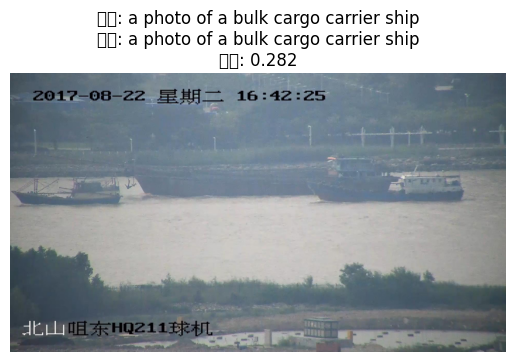

In [12]:
# 加载微调后的模型进行测试
from peft import PeftModel

base_model = CLIPModel.from_pretrained(MODEL_NAME)
model = PeftModel.from_pretrained(base_model, os.path.join(OUTPUT_DIR, "final_model"))
model.to(DEVICE)
model.eval()

# 随机选一张验证集图片
if val_loader:
    sample_images, sample_texts = next(iter(val_loader))
    idx = random.randint(0, len(sample_images)-1)
    test_image = sample_images[idx]
    true_text = sample_texts[idx]

    # 候选文本（可以用所有类别名生成）
    candidate_texts = [f"a photo of a {cls} ship" for cls in classes]

    inputs = processor(text=candidate_texts, images=test_image, return_tensors="pt", padding=True).to(DEVICE)
    with torch.no_grad():
        outputs = model(**inputs)
        logits = outputs.logits_per_image[0]
        probs = logits.softmax(dim=-1).cpu().numpy()

    # 显示结果
    plt.imshow(test_image)
    plt.axis('off')
    plt.title(f"真值: {true_text}\n预测: {candidate_texts[probs.argmax()]}\n概率: {probs.max():.3f}")
    plt.show()
else:
    print("无验证集，跳过演示")

In [ ]:
# 将输出目录打包，以便下载
!tar -czf clip_ship_output.tar.gz {OUTPUT_DIR}
print("打包完成，可下载 clip_ship_output.tar.gz")